# 5k PBMC CITE-seq — QC & preprocessing

Reads the 10x `filtered_feature_bc_matrix.h5` (Gene Expression + Antibody Capture),
runs standard scRNA QC (mito/ribo/hb metrics, cell/gene filtering, Scrublet doublet
removal), normalizes RNA and protein, computes RNA PCA and protein embeddings, and
builds two KNN graphs for downstream quantum-walk analysis. Outputs `.h5ad` files.

**KNN-graph note (step 14):** the RNA graph is built on the 8-D PCA space (PCA denoises
the 2000-HVG space, which is otherwise too high-dimensional and noisy for meaningful
Euclidean neighbors). The **protein graph is built on the full 32-marker scaled space,
NOT PCA** — the antibody panel is already low-dimensional and every marker is an
interpretable, high-signal measurement, so PCA→8 would smooth away exactly the
fine marker-level distinctions a quantum walk should feel. See the note before step 14.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
from pathlib import Path

sc.settings.verbosity = 1

# Paths are resolved relative to this notebook so it runs from a fresh clone.
HERE = Path.cwd()
DATA_PATH = HERE / "data" / "5k_pbmc_protein_v3_nextgem_filtered_feature_bc_matrix.h5"
OUT_DIR = HERE / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"10x input not found at {DATA_PATH}.\n"
        "It ships with the repository under "
        "docs/source/tutorials/Preprocessing/data/. If it is missing, download the "
        "'Feature / cell matrix HDF5 (filtered)' for the 5k PBMC "
        "(Next GEM 3' v3.1, TotalSeq-B) dataset from 10x Genomics:\n"
        "  https://www.10xgenomics.com/datasets/5-k-peripheral-blood-mononuclear-"
        "cells-pbm-cs-from-a-healthy-donor-with-cell-surface-proteins-next-gem-3-1-"
        "standard-3-1-0\n"
        f"and place it at {DATA_PATH}."
    )

adata_all = sc.read_10x_h5(str(DATA_PATH), gex_only=False)

adata_all.var_names_make_unique()
adata_all.obs_names_make_unique()

print(adata_all)
print(adata_all.var["feature_types"].value_counts())

AnnData object with n_obs × n_vars = 5527 × 33570
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    layers: None
feature_types
Gene Expression     33538
Antibody Capture       32
Name: count, dtype: int64


qbc/lib/python3.12/site-packages/scanpy/readwrite.py:322: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return AnnData(matrix, obs=obs_dict, var=var_dict)


In [2]:
rna = adata_all[:, adata_all.var["feature_types"] == "Gene Expression"].copy()
adt = adata_all[:, adata_all.var["feature_types"] == "Antibody Capture"].copy()
print("RNA:", rna.shape, "| ADT:", adt.shape)

RNA: (5527, 33538) | ADT: (5527, 32)


In [3]:
rna.layers["counts"] = rna.X.copy()

In [4]:
gene_names = rna.var_names.str.upper()

rna.var["mt"] = gene_names.str.startswith("MT-")
rna.var["ribo"] = gene_names.str.startswith(("RPS", "RPL"))
rna.var["hb"] = gene_names.str.match(r"^HB[AB]")

print("MT:", int(rna.var["mt"].sum()),
      "| Ribo:", int(rna.var["ribo"].sum()),
      "| Hb:", int(rna.var["hb"].sum()))

MT: 13 | Ribo: 104 | Hb: 3


In [5]:
sc.pp.calculate_qc_metrics(
    rna,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)
rna.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,5527.000000,5527.000000,5527.000000
mean,1795.484892,5990.152832,14.499464
std,963.762038,4494.203613,15.026707
min,58.000000,501.000000,0.000000
25%,1142.000000,2859.500000,6.213643
50%,1836.000000,5676.000000,7.998316
75%,2254.500000,7586.000000,13.614652
max,9367.000000,110711.000000,93.956955


In [6]:
min_genes = 200
max_pct_mt = 15

upper_genes = np.quantile(rna.obs["n_genes_by_counts"], 0.99)
upper_counts = np.quantile(rna.obs["total_counts"], 0.99)

keep_cells = (
    (rna.obs["n_genes_by_counts"] >= min_genes)
    & (rna.obs["pct_counts_mt"] <= max_pct_mt)
    & (rna.obs["n_genes_by_counts"] <= upper_genes)
    & (rna.obs["total_counts"] <= upper_counts)
)
print(f"Keeping {int(keep_cells.sum())} / {rna.n_obs} cells")

rna = rna[keep_cells].copy()
adt = adt[rna.obs_names, :].copy()

sc.pp.filter_genes(rna, min_cells=3)
print("After gene filter:", rna.shape)

Keeping 4143 / 5527 cells


After gene filter: (4143, 17838)


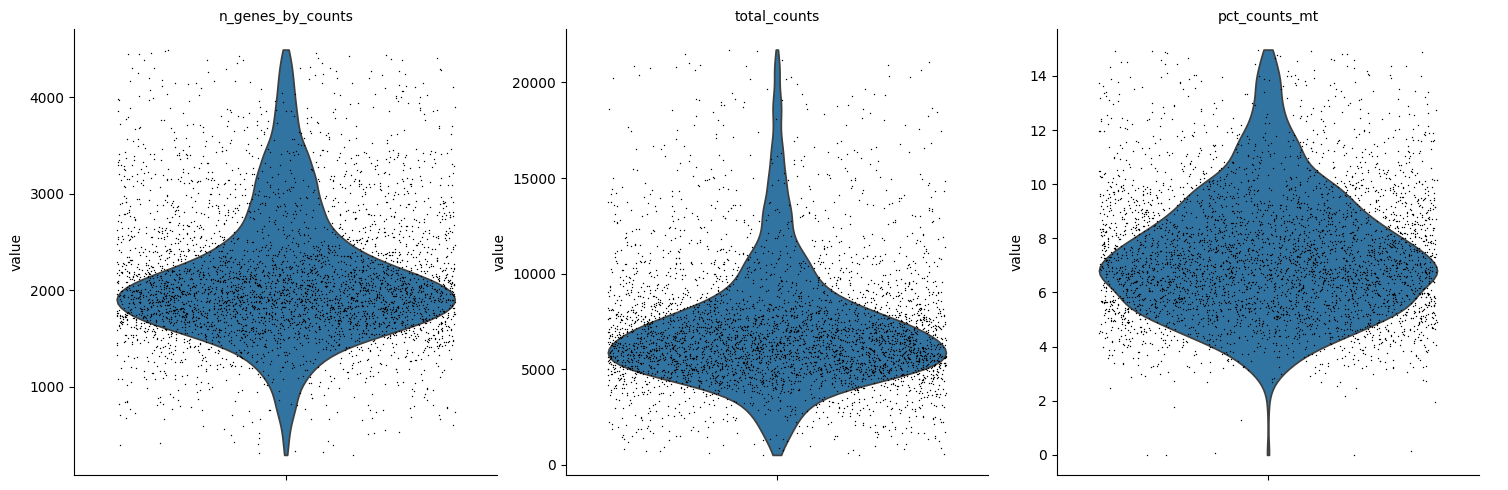

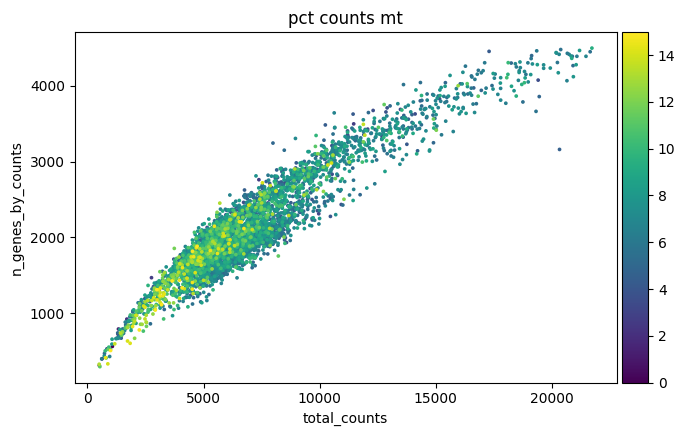

In [7]:
sc.pl.violin(
    rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

sc.pl.scatter(rna, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

In [8]:
rna_for_doublets = rna.copy()
rna_for_doublets.X = rna_for_doublets.layers["counts"].copy()

sc.pp.scrublet(rna_for_doublets)

rna.obs["doublet_score"] = rna_for_doublets.obs["doublet_score"]
rna.obs["predicted_doublet"] = rna_for_doublets.obs["predicted_doublet"]

n_db = int(rna.obs["predicted_doublet"].astype(bool).sum())
print(f"Predicted doublets: {n_db} / {rna.n_obs}")

rna = rna[~rna.obs["predicted_doublet"].astype(bool)].copy()
adt = adt[rna.obs_names, :].copy()
print("After doublet removal -> RNA:", rna.shape, "| ADT:", adt.shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Predicted doublets: 75 / 4143
After doublet removal -> RNA: (4068, 17838) | ADT: (4068, 32)


In [9]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
rna.raw = rna

In [10]:
sc.pp.highly_variable_genes(
    rna,
    n_top_genes=2000,
    flavor="seurat_v3",
    layer="counts",
)
print("Highly variable genes:", int(rna.var["highly_variable"].sum()))

Highly variable genes: 2000


In [11]:
rna_hvg = rna[:, rna.var["highly_variable"]].copy()

sc.pp.scale(rna_hvg, max_value=10)
sc.tl.pca(rna_hvg, n_comps=30, svd_solver="arpack")

rna.obsm["X_rna_pca"] = rna_hvg.obsm["X_pca"]
print("X_rna_pca:", rna.obsm["X_rna_pca"].shape)

/opt/homebrew/anaconda3/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


X_rna_pca: (4068, 30)


In [12]:
from sklearn.preprocessing import StandardScaler

def to_dense(X):
    return X.toarray() if sparse.issparse(X) else np.asarray(X)

protein_counts = to_dense(adt.X).astype(float)
protein_log = np.log1p(protein_counts)
protein_scaled = StandardScaler().fit_transform(protein_log)

rna.obsm["protein_counts"] = pd.DataFrame(
    protein_counts,
    index=rna.obs_names,
    columns=adt.var_names,
)

rna.obsm["X_protein"] = pd.DataFrame(
    protein_scaled,
    index=rna.obs_names,
    columns=adt.var_names,
)

rna.uns["protein_names"] = list(adt.var_names)
print("X_protein:", rna.obsm["X_protein"].shape)

X_protein: (4068, 32)


In [13]:
from sklearn.decomposition import PCA

X_rna8 = rna.obsm["X_rna_pca"][:, :8]

X_protein = np.asarray(rna.obsm["X_protein"])
if X_protein.shape[1] > 8:
    X_protein8 = PCA(n_components=8, random_state=0).fit_transform(X_protein)
else:
    X_protein8 = X_protein

rna.obsm["X_rna8"] = X_rna8
rna.obsm["X_protein8"] = X_protein8
print("X_rna8:", X_rna8.shape, "| X_protein8:", X_protein8.shape)

X_rna8: (4068, 8) | X_protein8: (4068, 8)


### Step 14 — KNN graphs (basis choice)

Two graphs are built with `k=15`, symmetrized (`A = max(A, Aᵀ)`), for quantum-walk analysis.

- **RNA → PCA basis (`X_rna8`).** RNA lives in a 2000-HVG space that is sparse and noise-dominated;
  Euclidean neighbors there are unreliable (curse of dimensionality). PCA is a denoising step, and the
  low-D manifold it produces *is* the biological structure a walk should traverse. Keep PCA.
- **Protein → raw scaled basis (`X_protein`, 32 markers, NOT PCA).** The antibody panel is already
  low-dimensional and each marker is a direct, interpretable readout (CD4/CD8/CD19/…, plus isotype
  controls). There is no curse-of-dimensionality problem to fix, and PCA→8 would smooth away the exact
  fine-grained marker contrasts the walk should feel. So the protein graph uses the full scaled space.

In [14]:
from sklearn.neighbors import kneighbors_graph

def make_knn_graph(X, k=15):
    X = np.ascontiguousarray(np.asarray(X, dtype=float))
    A = kneighbors_graph(
        X,
        n_neighbors=k,
        mode="connectivity",
        include_self=False,
    )
    A = A.maximum(A.T).tocsr()
    return A

# RNA: KNN on the 8-D denoised PCA space.
rna.obsp["rna_connectivities"] = make_knn_graph(rna.obsm["X_rna8"], k=15)

# Protein: KNN on the FULL 32-marker scaled space (NOT PCA) -- see note above.
rna.obsp["protein_connectivities"] = make_knn_graph(np.asarray(rna.obsm["X_protein"]), k=15)

rna.uns["rna_graph_basis"] = "X_rna8 (first 8 RNA PCs)"
rna.uns["protein_graph_basis"] = "X_protein (32 scaled ADT markers, no PCA)"

for name in ["rna_connectivities", "protein_connectivities"]:
    A = rna.obsp[name]
    print(f"{name}: shape={A.shape}, mean neighbors/cell={A.nnz / A.shape[0]:.2f}")

rna_connectivities: shape=(4068, 4068), mean neighbors/cell=20.87
protein_connectivities: shape=(4068, 4068), mean neighbors/cell=22.95


In [15]:
rna_out = OUT_DIR / "pbmc5k_citeseq_qc.h5ad"
adt_out = OUT_DIR / "pbmc5k_adt_raw.h5ad"

rna.write_h5ad(rna_out)
adt.write_h5ad(adt_out)

print("Wrote:", rna_out)
print("Wrote:", adt_out)
print(rna)

Wrote: outputs/pbmc5k_citeseq_qc.h5ad
Wrote: outputs/pbmc5k_adt_raw.h5ad
AnnData object with n_obs × n_vars = 4068 × 17838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'protein_names', 'rna_graph_basis', 'protein_graph_basis'
    obsm: 'X_rna_pca', 'protein_counts', 'X_protein', 'X_rna8', 'X_protein8'
    obsp: 'rna_connectivities', 'protein_connectivities'
    layers: None, 'counts'


---
# Part 2 — Cluster annotation & binary label creation

Cluster the QC'd cells (Leiden on RNA PCA), annotate broad PBMC cell types from
**cluster-level RNA markers + ADT sanity checks**, drop ambiguous/tiny clusters,
then collapse high-confidence annotations into binary classification tasks. Finally,
build leakage-aware feature sets and train/test + graph-diffusion splits, and save the
final labeled `.h5ad`.

In [16]:
# Neighbors on the denoised RNA PCA space, UMAP for viz, Leiden for clusters.
# NOTE: flavor="igraph" + fixed random_state make cluster IDs reproducible -- the
# annotation map further down is tied to THIS exact clustering. (The bare
# sc.tl.leiden(...) default is deprecated in scanpy 1.12 and less reproducible.)
sc.pp.neighbors(rna, use_rep="X_rna_pca", n_neighbors=15, random_state=0)
sc.tl.umap(rna, random_state=0)
sc.tl.leiden(
    rna,
    resolution=0.6,
    key_added="leiden_rna",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=0,
)
print("Leiden clusters:", rna.obs["leiden_rna"].nunique())
print(rna.obs["leiden_rna"].value_counts().sort_index())

qbc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden clusters: 11
leiden_rna
0     1098
1      128
2      168
3      867
4      353
5      683
6      156
7       94
8      348
9      164
10       9
Name: count, dtype: int64


In [17]:
marker_genes = {
    "T_cell": ["CD3D", "CD3E", "TRAC", "IL7R"],
    "CD4_T": ["CD4", "IL7R", "CCR7", "LTB"],
    "CD8_T": ["CD8A", "CD8B", "NKG7", "GZMK"],
    "B_cell": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "NK": ["NKG7", "GNLY", "PRF1", "KLRD1"],
    "Mono_CD14": ["LYZ", "S100A8", "S100A9", "FCN1", "LST1"],
    "Mono_FCGR3A": ["FCGR3A", "MS4A7", "LST1"],
    "DC": ["FCER1A", "CST3"],
    "Platelet": ["PPBP", "PF4"],
}

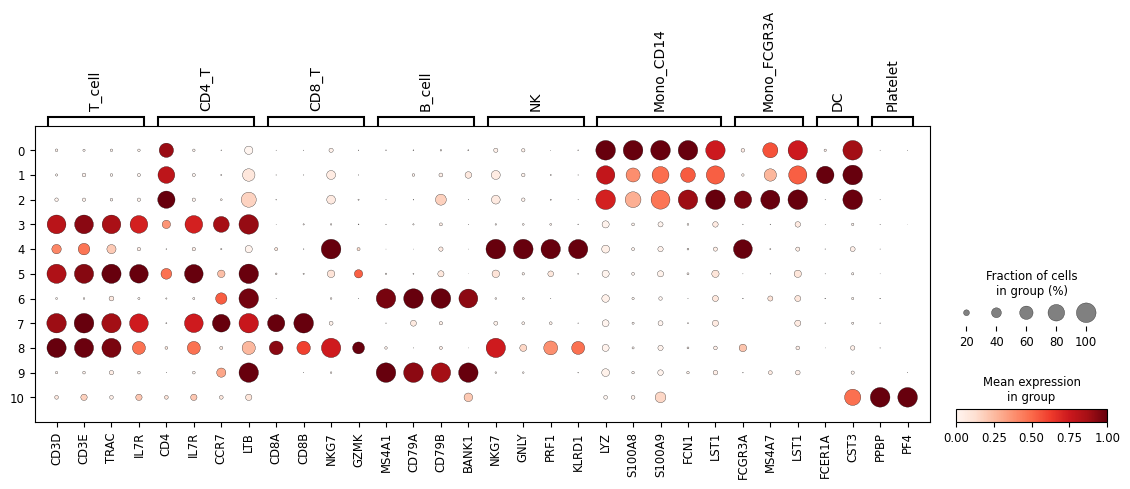

In [18]:
sc.pl.dotplot(
    rna,
    marker_genes,
    groupby="leiden_rna",
    standard_scale="var",
)

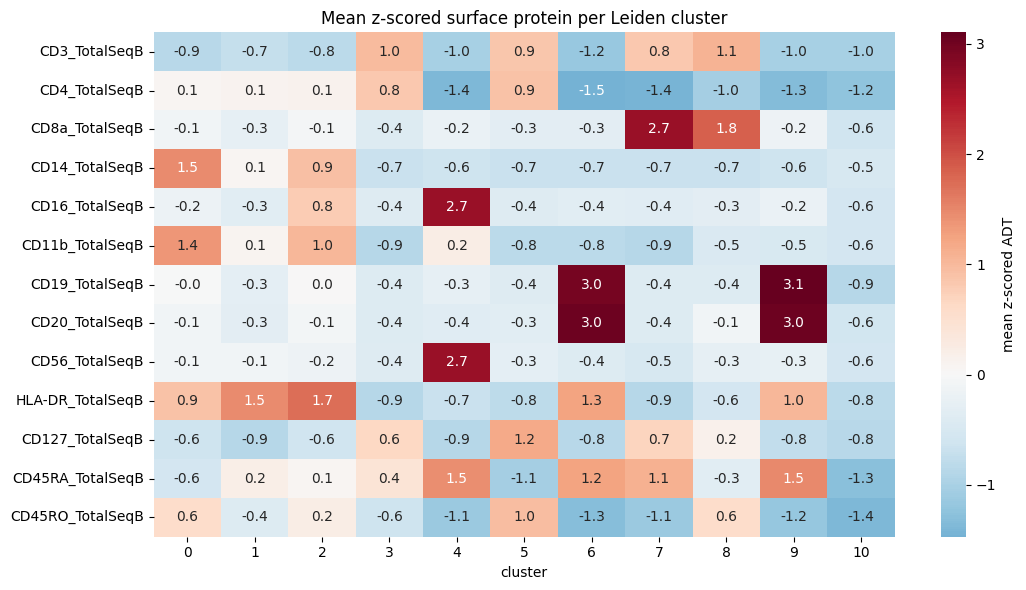

,CD3_TotalSeqB,CD4_TotalSeqB,CD8a_TotalSeqB,CD14_TotalSeqB,CD16_TotalSeqB,CD11b_TotalSeqB,CD19_TotalSeqB,CD20_TotalSeqB,CD56_TotalSeqB,HLA-DR_TotalSeqB,CD127_TotalSeqB,CD45RA_TotalSeqB,CD45RO_TotalSeqB
cluster,,,,,,,,,,,,,
0,-0.86,0.05,-0.10,1.47,-0.17,1.38,-0.02,-0.11,-0.10,0.90,-0.63,-0.56,0.58
1,-0.73,0.12,-0.28,0.08,-0.33,0.09,-0.31,-0.32,-0.10,1.46,-0.88,0.21,-0.40
2,-0.83,0.13,-0.06,0.94,0.78,1.03,0.03,-0.09,-0.15,1.74,-0.61,0.05,0.24
3,0.98,0.84,-0.42,-0.68,-0.39,-0.88,-0.42,-0.40,-0.39,-0.88,0.64,0.43,-0.65
4,-1.04,-1.38,-0.21,-0.64,2.67,0.24,-0.27,-0.38,2.69,-0.69,-0.89,1.45,-1.15
5,0.87,0.91,-0.31,-0.67,-0.38,-0.82,-0.39,-0.34,-0.31,-0.79,1.18,-1.05,0.96
6,-1.17,-1.47,-0.31,-0.67,-0.36,-0.83,2.96,3.02,-0.43,1.26,-0.85,1.23,-1.31
7,0.83,-1.42,2.69,-0.68,-0.38,-0.87,-0.43,-0.41,-0.52,-0.87,0.68,1.10,-1.13
8,1.07,-1.05,1.84,-0.68,-0.32,-0.46,-0.40,-0.10,-0.26,-0.56,0.17,-0.33,0.58


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

protein = rna.obsm["X_protein"]  # DataFrame (z-scored ADT)
protein_df = pd.DataFrame(
    np.asarray(protein),
    index=rna.obs_names,
    columns=rna.uns["protein_names"],
)
protein_df["cluster"] = rna.obs["leiden_rna"].values
cluster_protein_mean = protein_df.groupby("cluster").mean()

# Lineage-defining ADTs for the sanity check.
adt_key = [
    "CD3_TotalSeqB", "CD4_TotalSeqB", "CD8a_TotalSeqB",
    "CD14_TotalSeqB", "CD16_TotalSeqB", "CD11b_TotalSeqB",
    "CD19_TotalSeqB", "CD20_TotalSeqB", "CD56_TotalSeqB",
    "HLA-DR_TotalSeqB", "CD127_TotalSeqB", "CD45RA_TotalSeqB", "CD45RO_TotalSeqB",
]
plt.figure(figsize=(11, 6))
sns.heatmap(cluster_protein_mean[adt_key].T, center=0, cmap="RdBu_r",
            annot=True, fmt=".1f", cbar_kws={"label": "mean z-scored ADT"})
plt.title("Mean z-scored surface protein per Leiden cluster")
plt.tight_layout()
plt.show()

cluster_protein_mean[adt_key].round(2)

### Cluster annotation (evidence-based)

Derived from the RNA dotplot + ADT heatmap above. Cluster IDs come from the fixed
Leiden run, so this map is reproducible. This is **not** the generic example map — it
reflects the 11 clusters this dataset actually produces.

| Cluster | RNA evidence | ADT evidence | Call |
|--|--|--|--|
| 0 | LYZ/S100A8/S100A9/FCN1 hi | CD14⁺ CD11b⁺ | `CD14_monocyte` |
| 1 | FCER1A⁺ CST3⁺, CD14 low | HLA-DR⁺ CD14⁻ | `DC` |
| 2 | FCGR3A/MS4A7/LST1 hi | CD16⁺ | `FCGR3A_monocyte` |
| 3 | CD3D/E, IL7R, CCR7 | CD3⁺ CD4⁺ | `CD4_T` |
| 4 | NKG7/GNLY/PRF1/KLRD1 hi | CD56⁺ CD16⁺ CD3⁻ | `NK` |
| 5 | CD3, IL7R, LTB | CD3⁺ CD4⁺ CD127⁺ | `CD4_T` |
| 6 | MS4A1/CD79A/CD79B/BANK1 | CD19⁺ CD20⁺ | `B_cell` |
| 7 | CD8A/CD8B, CCR7 | CD8a⁺⁺ CD3⁺ | `CD8_T` |
| 8 | CD8A/B, NKG7, GZMK | CD8a⁺ CD3⁺ | `CD8_T` |
| 9 | MS4A1/CD79A/CD79B | CD19⁺ CD20⁺ | `B_cell` |
| 10 | PPBP/PF4 (n=9) | — | `platelet` → dropped (platelet-rich + very small) |

In [20]:
# Evidence-based map tied to the reproducible Leiden run above.
cluster_to_cell_type = {
    "0": "CD14_monocyte",
    "1": "DC",
    "2": "FCGR3A_monocyte",
    "3": "CD4_T",
    "4": "NK",
    "5": "CD4_T",
    "6": "B_cell",
    "7": "CD8_T",
    "8": "CD8_T",
    "9": "B_cell",
    "10": "platelet",  # platelet-rich + very small -> excluded below
}

rna.obs["cell_type"] = (
    rna.obs["leiden_rna"]
    .astype(str)
    .map(cluster_to_cell_type)
    .fillna("unknown")
    .astype("category")
)
print(rna.obs["cell_type"].value_counts())

cell_type
CD4_T              1550
CD14_monocyte      1098
CD8_T               442
NK                  353
B_cell              320
FCGR3A_monocyte     168
DC                  128
platelet              9
Name: count, dtype: int64


In [21]:
# Keep high-confidence lineages only; drop unknown / ambiguous / platelet-rich /
# very-small clusters. obsp graphs are auto-subset to the retained cells by AnnData.
usable_cell_types = [
    "CD4_T",
    "CD8_T",
    "CD14_monocyte",
    "FCGR3A_monocyte",
    "B_cell",
    "NK",
    "DC",
]
n_before = rna.n_obs
rna = rna[rna.obs["cell_type"].isin(usable_cell_types)].copy()
rna.obs["cell_type"] = rna.obs["cell_type"].cat.remove_unused_categories()
print(f"Dropped {n_before - rna.n_obs} cells; kept {rna.n_obs}")
print(rna.obs["cell_type"].value_counts())

Dropped 9 cells; kept 4059
cell_type
CD4_T              1550
CD14_monocyte      1098
CD8_T               442
NK                  353
B_cell              320
FCGR3A_monocyte     168
DC                  128
Name: count, dtype: int64


### Binary tasks

High-confidence annotations collapsed into three binary labels. Cells not participating
in a task are left as `NaN` (e.g. B/NK/DC carry no `binary_t_vs_mono` label).

In [22]:
# Task 1 (primary): T cells vs monocytes
t_cells = ["CD4_T", "CD8_T"]
monocytes = ["CD14_monocyte", "FCGR3A_monocyte"]
rna.obs["binary_t_vs_mono"] = pd.Series(index=rna.obs_names, dtype="object")
rna.obs.loc[rna.obs["cell_type"].isin(t_cells), "binary_t_vs_mono"] = "T_cell"
rna.obs.loc[rna.obs["cell_type"].isin(monocytes), "binary_t_vs_mono"] = "Monocyte"
rna.obs["binary_t_vs_mono"] = rna.obs["binary_t_vs_mono"].astype("category")

# Task 2 (backup): lymphoid vs myeloid
lymphoid = ["CD4_T", "CD8_T", "B_cell", "NK"]
myeloid = ["CD14_monocyte", "FCGR3A_monocyte", "DC"]
rna.obs["binary_lymphoid_vs_myeloid"] = pd.Series(index=rna.obs_names, dtype="object")
rna.obs.loc[rna.obs["cell_type"].isin(lymphoid), "binary_lymphoid_vs_myeloid"] = "Lymphoid"
rna.obs.loc[rna.obs["cell_type"].isin(myeloid), "binary_lymphoid_vs_myeloid"] = "Myeloid"
rna.obs["binary_lymphoid_vs_myeloid"] = rna.obs["binary_lymphoid_vs_myeloid"].astype("category")

# Task 3 (extension): CD4 vs CD8 T cells
rna.obs["binary_cd4_vs_cd8"] = pd.Series(index=rna.obs_names, dtype="object")
rna.obs.loc[rna.obs["cell_type"] == "CD4_T", "binary_cd4_vs_cd8"] = "CD4_T"
rna.obs.loc[rna.obs["cell_type"] == "CD8_T", "binary_cd4_vs_cd8"] = "CD8_T"
rna.obs["binary_cd4_vs_cd8"] = rna.obs["binary_cd4_vs_cd8"].astype("category")

for c in ["binary_t_vs_mono", "binary_lymphoid_vs_myeloid", "binary_cd4_vs_cd8"]:
    print(c, "->", rna.obs[c].value_counts(dropna=False).to_dict())

binary_t_vs_mono -> {'T_cell': 1992, 'Monocyte': 1266, nan: 801}
binary_lymphoid_vs_myeloid -> {'Lymphoid': 2665, 'Myeloid': 1394}
binary_cd4_vs_cd8 -> {nan: 2067, 'CD4_T': 1550, 'CD8_T': 442}


### Leakage-aware feature sets

The binary labels are defined *from* lineage markers, so leaving those markers in the
feature matrix lets a classifier trivially recover the label (leakage). We build two
feature sets over the modeling space (2000 HVGs + 32 ADTs): `all_features` and
`marker_removed_features` (the label-defining genes/proteins stripped out). Feature
names below match the actual 10x feature names in this dataset.

In [23]:
label_leakage_genes = [
    "CD3D", "CD3E", "TRAC",
    "CD4", "CD8A", "CD8B",
    "LYZ", "S100A8", "S100A9", "FCN1",
    "MS4A1", "CD79A", "CD79B",
]
label_leakage_proteins = [
    "CD3_TotalSeqB",
    "CD4_TotalSeqB",
    "CD8a_TotalSeqB",   # lowercase 'a' matches the 10x feature name
    "CD14_TotalSeqB",
    "CD16_TotalSeqB",
    "CD19_TotalSeqB",
]

present_leak_genes = [g for g in label_leakage_genes if g in rna.var_names]
present_leak_prot = [p for p in label_leakage_proteins if p in rna.uns["protein_names"]]

rna.var["is_label_leakage"] = rna.var_names.isin(present_leak_genes)

hvg_genes = rna.var_names[rna.var["highly_variable"]].tolist()
protein_names = list(rna.uns["protein_names"])

rna.uns["feature_sets"] = {
    "all_features": {"genes": hvg_genes, "proteins": protein_names},
    "marker_removed_features": {
        "genes": [g for g in hvg_genes if g not in present_leak_genes],
        "proteins": [p for p in protein_names if p not in present_leak_prot],
    },
    "label_leakage_genes": present_leak_genes,
    "label_leakage_proteins": present_leak_prot,
}

fs = rna.uns["feature_sets"]
print("all_features       :", len(fs["all_features"]["genes"]), "genes +",
      len(fs["all_features"]["proteins"]), "proteins")
print("marker_removed     :", len(fs["marker_removed_features"]["genes"]), "genes +",
      len(fs["marker_removed_features"]["proteins"]), "proteins")
print("removed leakage    :", len(present_leak_genes), "genes,",
      len(present_leak_prot), "proteins")

all_features       : 2000 genes + 32 proteins
marker_removed     : 1987 genes + 26 proteins
removed leakage    : 13 genes, 6 proteins


### Splits

- **`split`** — general stratified 70/30 train/test over *all usable cells* (stratified
  by `cell_type`) for standard ML/QML classifiers.
- **`graph_seed` / `graph_eval`** — the graph-diffusion partition for the **primary task**
  (`binary_t_vs_mono`): a small labeled seed set (30%) spreads class evidence over the
  cell-similarity graph; the held-out 70% (`graph_eval`) is used to recover labels.

*Seed labels = a few known cells · Graph = cell-state similarity network · Random walk =
spread class evidence · Evaluation = recover labels for held-out cells.*

In [24]:
from sklearn.model_selection import train_test_split

# General train/test split (stratified by cell type) for ML/QML.
train_all, test_all = train_test_split(
    rna.obs_names,
    test_size=0.3,
    random_state=7,
    stratify=rna.obs["cell_type"],
)
rna.obs["split"] = "train"
rna.obs.loc[test_all, "split"] = "test"
rna.obs["split"] = rna.obs["split"].astype("category")

# Graph-diffusion seed/eval for the primary task (few known seeds, many held-out).
task = "binary_t_vs_mono"
valid = rna.obs[task].notna()
cells = rna.obs_names[valid]
labels = rna.obs.loc[cells, task]

train_cells, test_cells = train_test_split(
    cells,
    test_size=0.7,
    random_state=7,
    stratify=labels,
)

rna.obs["graph_seed"] = False
rna.obs.loc[train_cells, "graph_seed"] = True

rna.obs["graph_eval"] = False
rna.obs.loc[test_cells, "graph_eval"] = True

print("split:", rna.obs["split"].value_counts().to_dict())
print(f"graph_seed (T/Mono): {int(rna.obs['graph_seed'].sum())} | "
      f"graph_eval: {int(rna.obs['graph_eval'].sum())}")

split: {'train': 2841, 'test': 1218}
graph_seed (T/Mono): 977 | graph_eval: 2281


In [25]:
rna.uns["labeling_notes"] = {
    "cell_type_method": "Leiden (res=0.6, igraph flavor, seed=0) on RNA PCA; "
                        "cluster-level RNA markers + ADT sanity checks",
    "primary_task": "T cells versus monocytes (binary_t_vs_mono)",
    "backup_task": "lymphoid versus myeloid (binary_lymphoid_vs_myeloid)",
    "extension_task": "CD4 versus CD8 T cells (binary_cd4_vs_cd8)",
    "excluded_cells": "unknown, ambiguous, platelet-rich (cluster 10, n=9) clusters",
    "leakage_handling": "marker_removed_features drops lineage-defining genes/proteins "
                        "to prevent trivial label recovery",
    "split": "70/30 train/test stratified by cell_type (random_state=7)",
    "graph_diffusion": "graph_seed=30% seeds / graph_eval=70% held-out for "
                       "binary_t_vs_mono (random_state=7)",
    "warning": "Labels are for tutorial/benchmarking, not a curated immune atlas.",
}

final_out = OUT_DIR / "pbmc5k_citeseq_labeled.h5ad"
rna.write_h5ad(final_out)
print("Wrote:", final_out)
print(rna)

Wrote: outputs/pbmc5k_citeseq_labeled.h5ad
AnnData object with n_obs × n_vars = 4059 × 17838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'leiden_rna', 'cell_type', 'binary_t_vs_mono', 'binary_lymphoid_vs_myeloid', 'binary_cd4_vs_cd8', 'split', 'graph_seed', 'graph_eval'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'is_label_leakage'
    uns: 'log1p', 'hvg', 'protein_names', 'rna_graph_basis', 'protein_graph_basis', 'neighbors', 'umap', 'leiden_rna', 'feature_sets', 'labeling_notes'
    obsm: 'X_rna_pca', 'protein_counts', 'X_protein', 'X_rna8', 'X_protein8', 'X_umap'
    obsp: 'rna_connectivities', 'protein_connecti

---
# Part 3 — Balanced subsampling & small downloadable benchmarks

Small, class-balanced sets sized for quantum / small-scale ML.

- **ML classification** — each cell is an independent sample, so we export a small
  self-contained `.h5ad` per binary task: **210 cells/class train + 40 cells/class test**
  (≈420 / ≈80), with KNN graphs **recomputed within the subset** so the small file works
  for both classical and graph-based models on its own.
- **Graph diffusion** — the graph is the *full* cell-similarity network, so we do **not**
  shrink it. Instead we add balanced seed/eval masks to the full object (kept intact) and
  give the graph task a little more headroom: **300 seeds/class + 100 eval/class**.

In [26]:
# Reproducible balanced sampler: pick n_train + n_test cells per class, disjoint.
N_TRAIN_PER_CLASS = 210
N_TEST_PER_CLASS = 40
# Graph diffusion gets a little more (full graph is retained).
N_SEED_PER_CLASS = 300
N_EVAL_PER_CLASS = 100

BINARY_TASKS = ["binary_t_vs_mono", "binary_lymphoid_vs_myeloid", "binary_cd4_vs_cd8"]


def balanced_split(label_series, n_train, n_test, seed=7):
    """Return (train_cells, test_cells) with equal cells per class, disjoint."""
    rng = np.random.default_rng(seed)
    labels = label_series.dropna()
    train, test = [], []
    for cls in sorted(labels.unique()):
        cells = labels.index[labels == cls].to_numpy()
        rng.shuffle(cells)
        need = n_train + n_test
        if len(cells) < need:
            raise ValueError(f"class {cls!r} has {len(cells)} cells < {need} requested")
        train += list(cells[:n_train])
        test += list(cells[n_train:need])
    return train, test

In [27]:
# Add a balanced train/test subsample column per binary task to the full object.
for task in BINARY_TASKS:
    tr, te = balanced_split(rna.obs[task], N_TRAIN_PER_CLASS, N_TEST_PER_CLASS, seed=7)
    col = f"subsample_{task.replace('binary_', '')}"
    rna.obs[col] = pd.Series(index=rna.obs_names, dtype="object")
    rna.obs.loc[tr, col] = "train"
    rna.obs.loc[te, col] = "test"
    rna.obs[col] = rna.obs[col].astype("category")
    print(f"{col}: train={len(tr)} test={len(te)} | per-class balance:")
    print("   ", rna.obs.loc[rna.obs[col].notna()].groupby(col, observed=True)[task]
          .value_counts().to_dict())

subsample_t_vs_mono: train=420 test=80 | per-class balance:
    {('test', 'Monocyte'): 40, ('test', 'T_cell'): 40, ('train', 'Monocyte'): 210, ('train', 'T_cell'): 210}
subsample_lymphoid_vs_myeloid: train=420 test=80 | per-class balance:
    {('test', 'Myeloid'): 40, ('test', 'Lymphoid'): 40, ('train', 'Myeloid'): 210, ('train', 'Lymphoid'): 210}
subsample_cd4_vs_cd8: train=420 test=80 | per-class balance:
    {('test', 'CD4_T'): 40, ('test', 'CD8_T'): 40, ('train', 'CD4_T'): 210, ('train', 'CD8_T'): 210}


In [28]:
# Balanced graph-diffusion seed/eval for the PRIMARY task on the FULL graph.
seed_cells, eval_cells = balanced_split(
    rna.obs["binary_t_vs_mono"], N_SEED_PER_CLASS, N_EVAL_PER_CLASS, seed=11
)
rna.obs["graph_seed_bal"] = False
rna.obs.loc[seed_cells, "graph_seed_bal"] = True
rna.obs["graph_eval_bal"] = False
rna.obs.loc[eval_cells, "graph_eval_bal"] = True

assert not (rna.obs["graph_seed_bal"] & rna.obs["graph_eval_bal"]).any()
print(f"graph_seed_bal: {int(rna.obs['graph_seed_bal'].sum())} "
      f"(seeds, {N_SEED_PER_CLASS}/class) | "
      f"graph_eval_bal: {int(rna.obs['graph_eval_bal'].sum())} "
      f"(held-out, {N_EVAL_PER_CLASS}/class) | full graph retained")

graph_seed_bal: 600 (seeds, 300/class) | graph_eval_bal: 200 (held-out, 100/class) | full graph retained


### Small self-contained benchmarks (one file per task)

Trimmed for demo: each file holds only its 500 subsampled cells, **2000 HVGs** (full-gene
matrix and `raw` dropped) plus the 32 ADTs in `obsm`, with a freshly computed within-subset KNN
graph (RNA on the 8-D PCA space, protein on the full 32-marker space — same bases as the
full object). Ready for classical ML, QML, or small-scale graph diffusion.

In [29]:
# `make_knn_graph` is defined in Part 1 (step 14) and reused here.
small_files = {}
for task in BINARY_TASKS:
    col = f"subsample_{task.replace('binary_', '')}"
    # Demo trim: keep 2000 HVGs only, drop full-gene X/raw. ADTs live in obsm.
    sub = rna[rna.obs[col].notna(), rna.var["highly_variable"]].copy()
    sub.raw = None

    # Rename the split column to a generic name and keep the active label handy.
    sub.obs["subsample_split"] = sub.obs[col].astype("category")
    sub.obs["label"] = sub.obs[task].astype("category")

    # Recompute walk graphs WITHIN the subset (the inherited full-graph obsp is dropped).
    for k in ["connectivities", "distances", "rna_connectivities", "protein_connectivities"]:
        sub.obsp.pop(k, None)
    sub.obsp["rna_connectivities"] = make_knn_graph(sub.obsm["X_rna8"], k=15)
    sub.obsp["protein_connectivities"] = make_knn_graph(np.asarray(sub.obsm["X_protein"]), k=15)

    sub.uns["subsample_notes"] = {
        "task": task,
        "n_train_per_class": N_TRAIN_PER_CLASS,
        "n_test_per_class": N_TEST_PER_CLASS,
        "graphs": "KNN (k=15) recomputed within this subset; "
                  "RNA on X_rna8 (PCA), protein on X_protein (32 markers)",
        "features": "2000 HVG genes (X, counts) + 32 ADTs (obsm); raw dropped",
        "parent": "pbmc5k_citeseq_labeled.h5ad",
    }

    out = OUT_DIR / f"pbmc5k_small_{task.replace('binary_', '')}.h5ad"
    sub.write_h5ad(out)
    small_files[task] = (out, sub.n_obs)
    print(f"{out.name}: {sub.n_obs} cells | "
          f"{sub.obs['subsample_split'].value_counts().to_dict()} | "
          f"labels {sub.obs['label'].value_counts().to_dict()}")

small_files

pbmc5k_small_t_vs_mono.h5ad: 500 cells | {'train': 420, 'test': 80} | labels {'Monocyte': 250, 'T_cell': 250}


pbmc5k_small_lymphoid_vs_myeloid.h5ad: 500 cells | {'train': 420, 'test': 80} | labels {'Lymphoid': 250, 'Myeloid': 250}


pbmc5k_small_cd4_vs_cd8.h5ad: 500 cells | {'train': 420, 'test': 80} | labels {'CD4_T': 250, 'CD8_T': 250}


{'binary_t_vs_mono': (PosixPath('outputs/pbmc5k_small_t_vs_mono.h5ad'),
  500),
 'binary_lymphoid_vs_myeloid': (PosixPath('outputs/pbmc5k_small_lymphoid_vs_myeloid.h5ad'),
  500),
 'binary_cd4_vs_cd8': (PosixPath('outputs/pbmc5k_small_cd4_vs_cd8.h5ad'),
  500)}

In [30]:
# Re-save the full object with the new balanced subsample / graph columns.
final_out = OUT_DIR / "pbmc5k_citeseq_labeled.h5ad"
rna.write_h5ad(final_out)
print("Updated full object:", final_out)
print("New obs columns:",
      [c for c in rna.obs.columns if c.startswith(("subsample_", "graph_seed_bal", "graph_eval_bal"))])

Updated full object: outputs/pbmc5k_citeseq_labeled.h5ad
New obs columns: ['subsample_t_vs_mono', 'subsample_lymphoid_vs_myeloid', 'subsample_cd4_vs_cd8', 'graph_seed_bal', 'graph_eval_bal']


---
# Part 4 — Graph-only benchmark (soft seeds / eval)

A mid-size, download-friendly file for full-*graph* diffusion on the primary task
(T vs monocyte). The 3,258 T/Mono cells are subsampled to **~800 balanced nodes
(400/class)**; the KNN graphs are **recomputed on those nodes** so the network is intact
at this scale (not a sparse slice of the big graph). `.raw` and the full-gene matrix are
dropped (2000 HVGs kept) so the file downloads at a few MB.

**Soft seeds/eval.** Diffusion is seeded from a soft label matrix `obsm["Y_soft"]`
(columns `[T_cell, Monocyte]`):
- **seed** nodes (100/class) carry a *soft* one-hot — confidence `alpha=0.9` on the true
  class, `0.1` on the other (soft, not hard 1/0, so a walk can still revise them);
- **eval** nodes (300/class) carry a uniform prior `[0.5, 0.5]` (unknown) and are scored
  against ground truth after diffusion.

In [31]:
# Build the ~800-node graph benchmark for binary_t_vs_mono.
N_NODES_PER_CLASS = 400      # 800 nodes total, balanced
N_SEED_PER_CLASS = 100       # soft seeds
N_EVAL_PER_CLASS = 300       # soft eval (held-out); 100 + 300 = 400 per class
ALPHA = 0.9                  # seed confidence (soft one-hot)
CLASS_ORDER = ["T_cell", "Monocyte"]   # column order of Y_soft

rng = np.random.default_rng(23)
tvm = rna.obs["binary_t_vs_mono"].dropna()

# 1) pick 400 nodes/class, then split each class into seed/eval
node_cells, seed_cells, eval_cells = [], [], []
for cls in CLASS_ORDER:
    cells = tvm.index[tvm == cls].to_numpy()
    rng.shuffle(cells)
    chosen = cells[:N_NODES_PER_CLASS]
    node_cells += list(chosen)
    seed_cells += list(chosen[:N_SEED_PER_CLASS])
    eval_cells += list(chosen[N_SEED_PER_CLASS:N_NODES_PER_CLASS])

g = rna[node_cells, rna.var["highly_variable"]].copy()
g.raw = None

# 2) recompute the walk graphs on these 800 nodes (RNA on PCA, protein on 32 markers)
for k in ["connectivities", "distances", "rna_connectivities", "protein_connectivities"]:
    g.obsp.pop(k, None)
g.obsp["rna_connectivities"] = make_knn_graph(g.obsm["X_rna8"], k=15)
g.obsp["protein_connectivities"] = make_knn_graph(np.asarray(g.obsm["X_protein"]), k=15)

# 3) roles + hard masks
seed_set, eval_set = set(seed_cells), set(eval_cells)
g.obs["graph_role"] = pd.Categorical(
    ["seed" if c in seed_set else "eval" for c in g.obs_names],
    categories=["seed", "eval"],
)
g.obs["graph_seed"] = g.obs["graph_role"] == "seed"
g.obs["graph_eval"] = g.obs["graph_role"] == "eval"
g.obs["label"] = g.obs["binary_t_vs_mono"].astype("category")
g.obs["label_int"] = g.obs["label"].map({c: i for i, c in enumerate(CLASS_ORDER)}).astype(int)

# 4) soft label-initialization matrix Y_soft (n x 2)
Y = np.full((g.n_obs, len(CLASS_ORDER)), 0.5, dtype=float)   # eval/unknown = uniform prior
for i, c in enumerate(g.obs_names):
    if c in seed_set:
        j = CLASS_ORDER.index(g.obs["label"].iloc[i])
        Y[i, :] = 1.0 - ALPHA
        Y[i, j] = ALPHA
g.obsm["Y_soft"] = Y

g.uns["graph_benchmark_notes"] = {
    "task": "binary_t_vs_mono",
    "n_nodes": int(g.n_obs),
    "n_seed_per_class": N_SEED_PER_CLASS,
    "n_eval_per_class": N_EVAL_PER_CLASS,
    "seed_confidence_alpha": ALPHA,
    "class_order": CLASS_ORDER,
    "Y_soft": "n x 2 soft label init: seeds=soft one-hot (alpha), eval=uniform [0.5,0.5]",
    "graphs": "KNN k=15 recomputed on these nodes; RNA on X_rna8 (PCA), protein on X_protein",
    "usage": "diffuse Y_soft over obsp['rna_connectivities']; score argmax on graph_eval vs label",
    "parent": "pbmc5k_citeseq_labeled.h5ad",
}

out = OUT_DIR / "pbmc5k_graph_t_vs_mono.h5ad"
g.write_h5ad(out)
print(f"Wrote {out.name}: {g.n_obs} nodes x {g.n_vars} HVGs")
print("  roles:", g.obs["graph_role"].value_counts().to_dict())
print("  seed label balance:", g.obs.loc[g.obs["graph_seed"], "label"].value_counts().to_dict())
print("  eval label balance:", g.obs.loc[g.obs["graph_eval"], "label"].value_counts().to_dict())
print("  Y_soft rows (seed example):", Y[g.obs["graph_seed"].values][0],
      "| eval example:", Y[g.obs["graph_eval"].values][0])
print("  rna graph:", g.obsp["rna_connectivities"].shape,
      "mean_nbr=%.1f" % (g.obsp["rna_connectivities"].nnz / g.n_obs))

Wrote pbmc5k_graph_t_vs_mono.h5ad: 800 nodes x 2000 HVGs
  roles: {'eval': 600, 'seed': 200}
  seed label balance: {'Monocyte': 100, 'T_cell': 100}
  eval label balance: {'Monocyte': 300, 'T_cell': 300}
  Y_soft rows (seed example): [0.9 0.1] | eval example: [0.5 0.5]
  rna graph: (800, 800) mean_nbr=20.5
